# Jigsaw Puzzle Reconstruction using Deep Learning (JigNet)

This notebook demonstrates a complete end-to-end pipeline to solve 4x4 jigsaw puzzles. It loads and normalizes puzzle tiles from metadata, builds a Deep Learning model (`JigNet`) using PyTorch to predict pairwise spatial relationships (Left, Right, Up, Down, No Match) between tiles, trains it with weighted cross-entropy loss.

### Mount Google Drive
We mount Google Drive to access the puzzle tile image datasets, metadata files, and save model training checkpoints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Import dependencies**

In [ ]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import shutil
from IPython.display import clear_output
import glob
import pulp
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import seaborn as sns

### 2. Device Configuration
We check if a CUDA-capable GPU is available to accelerate neural network training and validation.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


### 3. Training & Dataset Configurations
Define the paths, batch size, learning rates, epochs, and mean/standard deviation normalization values derived from our training set.

In [ ]:
# dataset directory
pairs_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/pairs.csv"

# custom mean and std for normalization (see the cell below for further details)
mean = [0.5452349781990051, 0.6246451139450073, 0.4715678095817566]
std = [0.23454082012176514, 0.19042210280895233, 0.21782392263412476]

# class weights calculated in order to use weighted cross_entropy loss (see the cell below for further details)
class_weights = torch.tensor([0.3000, 2.4000, 2.4000, 2.4000, 2.4000])

batch_size = 128
num_epochs = 24
learning_rate = 1e-3

# save checkpoints and results to this directory
checkpoint_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoints will be saved to: {checkpoint_dir}")

Checkpoints will be saved to: /content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints


### 4. Custom Dataset Class
We define a custom PyTorch `Dataset` that reads pairs of image tiles from the metadata CSV, converts them to RGB, applies normalization transformations, and yields them with their positional labels.

In [ ]:
class Jigsaw_Dataset(Dataset):
  def __init__(self, pairs_csv, split, transform=None):
    df = pd.read_csv(pairs_csv)
    self.data = df[df['split'] == split]
    self.transform = transform

  def __len__(self):
    return len(self.data.index)

  def __getitem__(self, idx):
    # 1. Get paths + label from CSV
    row = self.data.iloc[idx]
    tile_path_a = row['tile_path_a']
    tile_path_b = row['tile_path_b']
    label = row['label']

    # 2. Read images
    tile_a = cv2.imread(tile_path_a)
    tile_b = cv2.imread(tile_path_b)

    if tile_a is None or tile_b is None:
      raise ValueError(f"Failed to read image at path: {tile_path_a} or {tile_path_b}")


    # 3. BGR → RGB
    tile_a = cv2.cvtColor(tile_a, cv2.COLOR_BGR2RGB)
    tile_b = cv2.cvtColor(tile_b, cv2.COLOR_BGR2RGB)

    # 4. Transform
    if self.transform is not None:
      tile_a = self.transform(tile_a)
      tile_b = self.transform(tile_b)

    # 5. Convert label to a PyTorch tensor
    label = torch.tensor(label, dtype=torch.long)

    # 5. Return
    return tile_a, tile_b, label



### Mean & Std Calculation (Optional)
This cell contains commented-out code showing how the dataset's channel-wise mean and standard deviation statistics were calculated for normalization.

If you're using the provided Jigsaw_Puzzels dataset, you can use the mean and standard deviation defined above in the configurations cell. Otherwise, run this cell to calculate them. Make sure to modify the parameters to match your specifications.

In [ ]:
"""
# Step 1: Initialize dataset with ONLY ToTensor()
train_dataset = Jigsaw_Dataset(
    pairs_csv=pairs_csv,
    split = 'train',
    transform=transforms.ToTensor()
)

# Step 2: Pass dataset to DataLoader
loader = DataLoader(train_dataset, batch_size=128, num_workers=2, pin_memory=True, shuffle=False)

# Step 3: Compute mean and std across both tile_a and tile_b
pixels_sum = torch.zeros(3)
sq_pixels_sum = torch.zeros(3)
num_pixels = 0

for tile_a, tile_b, _ in loader:
  # Concatenate tile_a and tile_b along batch dimension -> shape: [2 * batch_size, C, H, W]
  all_tiles = torch.cat([tile_a, tile_b], dim=0)

  batch_count = all_tiles.size(0)

  # Flatten spatial dimensions: [2 * batch_size, channels, H * W]
  all_tiles = all_tiles.view(batch_count, all_tiles.size(1), -1)

  # [R_total, G_total, B_total] , [ΣR², ΣG², ΣB²] , [num_R, num_G, num_B]
  pixels_sum += all_tiles.sum(dim=(0,2))
  sq_pixels_sum += all_tiles.pow(2).sum(dim=(0,2))
  num_pixels += all_tiles.size(0) * all_tiles.size(2)

# Accumulate mean and std over spatial pixels
# [R_mean, G_mean, B_mean]
mean = pixels_sum / num_pixels
# [R_std, G_std, B_std]
std = (sq_pixels_sum / num_pixels - mean.pow(2)).sqrt()

calculated_mean = mean.tolist()
calculated_std = std.tolist()

print("Calculated Mean:", calculated_mean)
print("Calculated Std: ", calculated_std)
"""


### 5. Instantiating Datasets and Dataloaders
Define PyTorch `DataLoader` objects for the training, validation, and test splits to facilitate batched training with shuffling.

In [ ]:
# 1.Transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 2.Dataset objects
train_dataset = Jigsaw_Dataset(pairs_csv, split='train', transform=train_transform)

val_dataset = Jigsaw_Dataset(pairs_csv, split='val', transform=val_transform)

test_dataset = Jigsaw_Dataset(pairs_csv, split='test', transform=test_transform)

# Dataloader objects
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Training samples:   74304
Validation samples: 9360
Test samples:       9360


### Dataset Verification
We load a sample batch to verify tensor shapes, data types, and check that all 5 target classes are represented correctly.

In [ ]:
tile_a, tile_b, labels = next(iter(train_loader))

print("Tile A shape:", tile_a.shape)
print("Tile B shape:", tile_b.shape)
print("Labels shape:", labels.shape)

print("Tile A dtype:", tile_a.dtype)
print("Tile B dtype:", tile_b.dtype)
print("Labels dtype:", labels.dtype)

print("Unique labels:", torch.unique(labels))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tile A shape: torch.Size([128, 3, 128, 128])
Tile B shape: torch.Size([128, 3, 128, 128])
Labels shape: torch.Size([128])
Tile A dtype: torch.float32
Tile B dtype: torch.float32
Labels dtype: torch.int64
Unique labels: tensor([0, 1, 2, 3, 4])


### 6. Neural Network Encoder (`JigEncoder`)
Define a Convolutional Neural Network (CNN) architecture to extract high-dimensional semantic feature maps from individual image tiles.

In [ ]:
class JigEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # Input: (B, 3, 128, 128)
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # (B, 32, 64, 64)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                          # (B, 32, 32, 32)

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),# (B, 64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                          # (B, 64, 16, 16)

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),# (B, 128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                          # (B, 128, 8, 8)

            # Reduce spatial dimensions without losing all spatial layout
            nn.AdaptiveAvgPool2d(output_size=(2, 2)),             # (B, 128, 2, 2)
            nn.Flatten()                                          # (B, 512)
        )

    def forward(self, x):
        return self.encoder(x)

### 7. Core Architecture (`JigNet`)
Define the full Siamese network model which uses our encoder to extract features from both tile_a and tile_b, calculates their differences and products, and feeds them into a Multi-Layer Perceptron (MLP) for classification.

In [ ]:
class JigNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.encoder = JigEncoder()

        # Feature dimension per tile = 128 * 2 * 2 = 512
        feature_dim = 512

        # Input features to MLP: [F_a, F_b, |F_a - F_b|, F_a * F_b]
        combined_dim = feature_dim * 4

        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, tile_a, tile_b):
        feature_a = self.encoder(tile_a)
        feature_b = self.encoder(tile_b)

        # 1. Direct concatenation
        # 2. Absolute Difference (measures distance/dissimilarity)
        # 3. Element-wise product (measures joint alignment/correlation)
        diff = torch.abs(feature_a - feature_b)
        prod = feature_a * feature_b

        combined = torch.cat([feature_a, feature_b, diff, prod], dim=1)

        logits = self.mlp(combined)
        return logits

### 8. Checkpoint Serialization
Define a helper utility to save our model weights, optimizer/scheduler state, and historical metrics to Google Drive periodically during training.

In [ ]:
def save_checkpoint(
    model,
    optimizer,
    epoch,
    train_losses,
    val_losses,
    train_accuracies,
    val_accuracies,
    checkpoint_dir,
    scheduler # Add scheduler to arguments
):

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_epoch_{epoch:03d}.pth"
    )

    checkpoint = {
        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), # Save scheduler state

        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,

        "learning_rate": learning_rate,

        "num_classes": 5
    }

    torch.save(checkpoint, checkpoint_path)

    print(f"Checkpoint saved: {checkpoint_path}")

### Checkpoint Recovery
Define a utility to look up the latest trained checkpoint from the directory structure for seamless training resumption.

In [ ]:
def get_latest_checkpoint(checkpoint_dir):

    checkpoints = glob.glob(
        os.path.join(
            checkpoint_dir,
            "checkpoint_epoch_*.pth"
        )
    )

    if not checkpoints:
        return None

    checkpoints.sort()

    return checkpoints[-1]

### Balancing Class Weights
This cell demonstrates how class imbalance in our training pairs was analyzed and used to compute balanced weights for the Cross-Entropy loss function.

For our dataset the class_weights was defined in the configuration for a quick access. If you wish to get the class weights for different dataset you can run the cell below.

In [ ]:
"""
# Class counts from the training set
class_counts = train_dataset.data["label"].value_counts().sort_index()

print("Class counts:")
print(class_counts)

# Number of classes
num_classes = len(class_counts)

# Total number of training samples
total_samples = class_counts.sum()

# Compute balanced class weights
class_weights = total_samples / (num_classes * class_counts)

print("\nClass weights:")
print(class_weights)

# Convert to PyTorch tensor
class_weights = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)

print("\nClass weights tensor:")
print(class_weights)
"""

Class counts:
label
0    49536
1     6192
2     6192
3     6192
4     6192
Name: count, dtype: int64

Class weights:
label
0    0.3
1    2.4
2    2.4
3    2.4
4    2.4
Name: count, dtype: float64

Class weights tensor:
tensor([0.3000, 2.4000, 2.4000, 2.4000, 2.4000])


### Optimization Setup & Model Initialization
We initialize our model, loss criteria (with class weights), optimizer (Adam), and learning rate scheduler (Cosine Annealing), loading from a checkpoint if one exists.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR


latest_checkpoint = get_latest_checkpoint(checkpoint_dir)

model = JigNet(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

# Fix T_max to use num_epochs
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

if latest_checkpoint is not None:
    print(f"Loading checkpoint:\n{latest_checkpoint}")

    checkpoint = torch.load(
        latest_checkpoint,
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        print("✓ Scheduler state loaded.")
    else:
        print("No scheduler state found in checkpoint. Starting scheduler from scratch.")

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    train_accuracies = checkpoint["train_accuracies"]
    val_accuracies = checkpoint["val_accuracies"]

    start_epoch = checkpoint["epoch"]
    print(f"✓ Resuming from epoch {start_epoch}")

else:
    print("No checkpoint found. Starting from scratch.")
    start_epoch = 0
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

Loading checkpoint:
/content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints/checkpoint_epoch_024.pth
✓ Scheduler state loaded.
✓ Resuming from epoch 24


### Dry Run Verification
Execute a single-batch training pass to verify the forward and backward passes execute successfully without memory errors.

In [ ]:
"""
model.train()

tile_a, tile_b, target = next(iter(train_loader))

tile_a = tile_a.to(device)
tile_b = tile_b.to(device)
target = target.to(device)

optimizer.zero_grad()

logits = model(tile_a, tile_b)

loss = criterion(logits, target)

loss.backward()

optimizer.step()

print("Mini training step successful!")
print("Loss:", loss.item())
"""

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Mini training step successful!
Loss: 1.7302649021148682


### 9. Main Model Training Loop
We perform iterative model training, validation performance recording, and real-time visualization of loss and accuracy curves over training epochs.

In [ ]:
for epoch in range(start_epoch, num_epochs):

    current_epoch = epoch + 1

    print(f"\nEpoch {current_epoch}/{num_epochs}")
    print("-" * 60)

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for tile_a, tile_b, target in train_loader:

        tile_a = tile_a.to(device)
        tile_b = tile_b.to(device)
        target = target.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward
        logits = model(tile_a, tile_b)

        # Loss
        loss = criterion(logits, target)

        # Backward
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_train_loss += loss.item() * target.size(0)

        # Track accuracy
        predictions = torch.argmax(logits, dim=1)

        train_correct += (
            predictions == target
        ).sum().item()

        train_total += target.size(0)


    # Average training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for tile_a, tile_b, target in val_loader:

            tile_a = tile_a.to(device)
            tile_b = tile_b.to(device)
            target = target.to(device)

            # Forward
            logits = model(tile_a, tile_b)

            # Loss
            loss = criterion(logits, target)

            # Track loss
            running_val_loss += loss.item() * target.size(0)

            # Predictions
            predictions = torch.argmax(logits, dim=1)

            val_correct += (
                predictions == target
            ).sum().item()

            val_total += target.size(0)


    # Average validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # --------------------------------------------------------
    # PRINT EPOCH RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:03d}/{num_epochs:03d}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%}"
    )


    # --------------------------------------------------------
    # LIVE PLOTS
    # --------------------------------------------------------

    clear_output(wait=True)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    epochs = range(1, epoch + 2)


    # Loss
    axes[0].plot(
        epochs,
        train_losses,
        label="Training Loss"
    )

    axes[0].plot(
        epochs,
        val_losses,
        label="Validation Loss"
    )

    axes[0].set_title(
        "Training and Validation Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[0].legend()
    axes[0].grid(True)


    # Accuracy
    axes[1].plot(
        epochs,
        train_accuracies,
        label="Training Accuracy"
    )

    axes[1].plot(
        epochs,
        val_accuracies,
        label="Validation Accuracy"
    )

    axes[1].set_title(
        "Training and Validation Accuracy"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    axes[1].legend()
    axes[1].grid(True)


    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # UPDATE LEARNING RATE SCHEDULER
    # --------------------------------------------------------
    scheduler.step() # Update learning rate

    # --------------------------------------------------------
    # TRAINING NOTES
    # --------------------------------------------------------

    print(f"\nEpoch {epoch + 1} Summary")
    print("-" * 55)

    print(
        f"Training   → "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_accuracy:.2%}"
    )

    print(
        f"Validation → "
        f"Loss: {val_loss:.4f} | "
        f"Accuracy: {val_accuracy:.2%}"
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if current_epoch % 2 == 0:

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=current_epoch,

            train_losses=train_losses,
            val_losses=val_losses,

            train_accuracies=train_accuracies,
            val_accuracies=val_accuracies,

            checkpoint_dir=checkpoint_dir,
            scheduler=scheduler # Pass the scheduler
        )

        print(
            f"✓ Checkpoint created at epoch {current_epoch}"
        )

### Model Evaluation & Metric Plotting
Once training concludes, we plot training versus validation metrics to check for overfitting and identify the best epoch using accuracy and loss criteria.

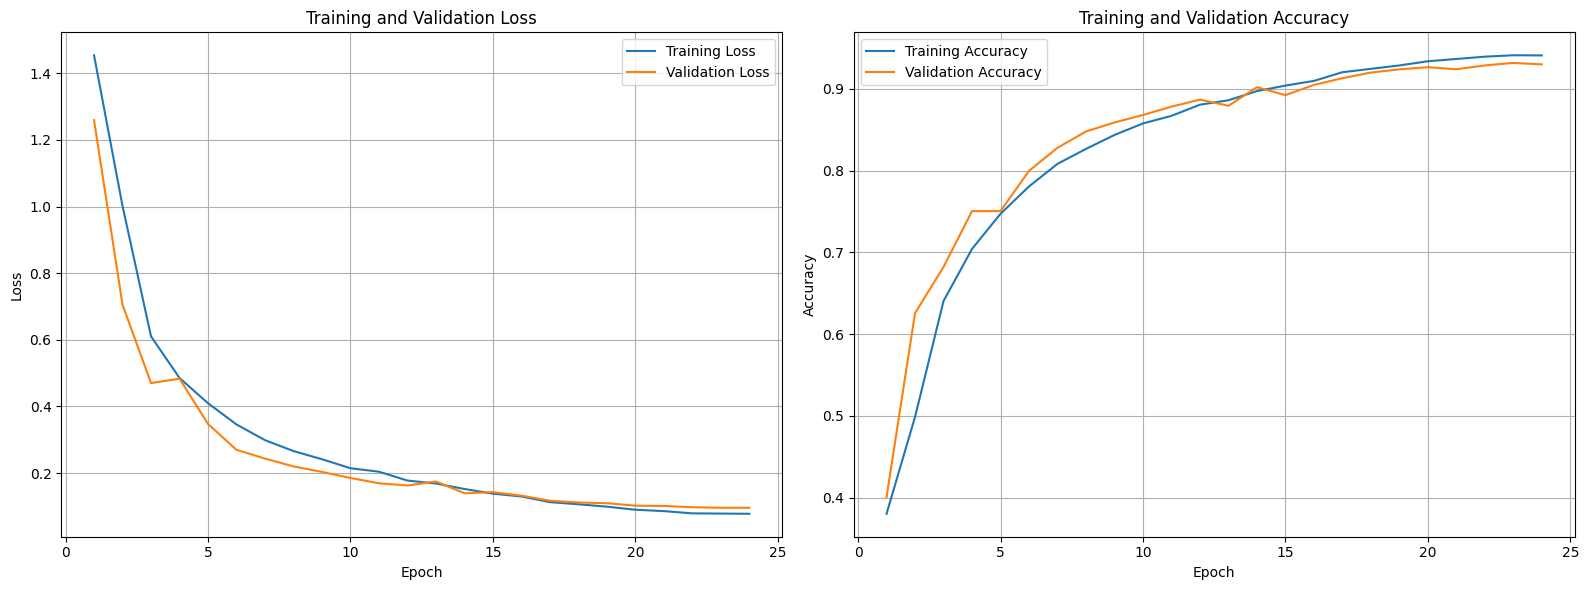


--- Best Model/Epoch Analysis ---
Best Validation Accuracy: 93.17% at Epoch 23
Corresponding Training Accuracy: 94.11%
Corresponding Validation Loss: 0.0957
Corresponding Training Loss: 0.0783

Lowest Validation Loss: 0.0957 at Epoch 24
Corresponding Training Loss: 0.0776
Corresponding Validation Accuracy: 92.99%
Corresponding Training Accuracy: 94.09%


In [ ]:
epochs = range(1, len(train_losses) + 1)

# Plotting the history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Loss
axes[0].plot(epochs, train_losses, label='Training Loss')
axes[0].plot(epochs, val_losses, label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plotting Accuracy
axes[1].plot(epochs, train_accuracies, label='Training Accuracy')
axes[1].plot(epochs, val_accuracies, label='Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Determine the best model/epoch based on validation metrics
best_val_accuracy = max(val_accuracies)
best_acc_epoch = val_accuracies.index(best_val_accuracy) + 1
best_val_loss = min(val_losses)
best_loss_epoch = val_losses.index(best_val_loss) + 1


print(f"\n--- Best Model/Epoch Analysis ---")
print(f"Best Validation Accuracy: {best_val_accuracy:.2%} at Epoch {best_acc_epoch}")
print(f"Corresponding Training Accuracy: {train_accuracies[best_acc_epoch - 1]:.2%}")
print(f"Corresponding Validation Loss: {val_losses[best_acc_epoch - 1]:.4f}")
print(f"Corresponding Training Loss: {train_losses[best_acc_epoch - 1]:.4f}")

print(f"\nLowest Validation Loss: {best_val_loss:.4f} at Epoch {best_loss_epoch}")
print(f"Corresponding Training Loss: {train_losses[best_loss_epoch - 1]:.4f}")
print(f"Corresponding Validation Accuracy: {val_accuracies[best_loss_epoch - 1]:.2%}")
print(f"Corresponding Training Accuracy: {train_accuracies[best_loss_epoch - 1]:.2%}")

### Confusion Matrix & F1 Performance (Validation)
We construct a Confusion Matrix and compute Macro and Weighted F1-Scores to examine model performance on individual spatial relationship categories on validation data.

Loading model from: /content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints/checkpoint_epoch_024.pth


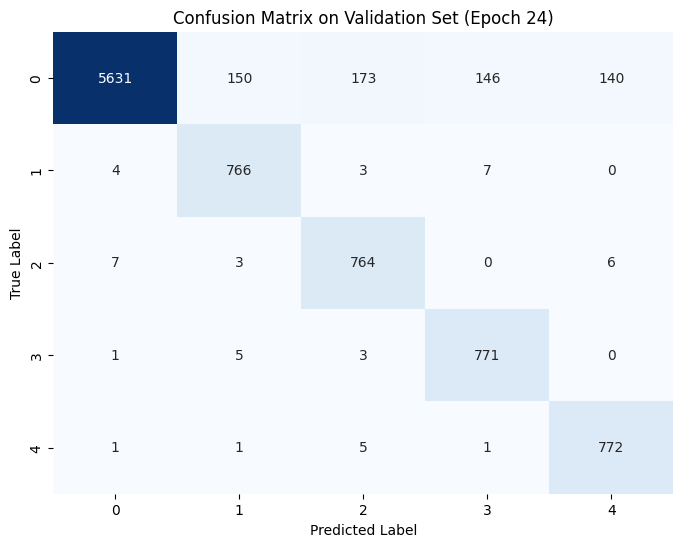


--- Confusion Matrix Explanation ---
Rows represent the TRUE LABELS (ground truth).
Columns represent the PREDICTED LABELS by the model.
Diagonal elements show correct classifications.
Off-diagonal elements show misclassifications (e.g., row 0, col 1 means samples of true class 0 were predicted as class 1).

Macro F1-Score on Validation Set: 0.9088
Weighted F1-Score on Validation Set: 0.9315


In [ ]:
# Get the path to the latest checkpoint
latest_checkpoint_path = get_latest_checkpoint(checkpoint_dir)

if latest_checkpoint_path is None:
    print("No checkpoint found in the directory. Please ensure checkpoints are saved.")
else:
    print(f"Loading model from: {latest_checkpoint_path}")

    # Load the checkpoint
    # Ensure model (JigNet) and device are defined from previous cells
    model_loaded = JigNet(num_classes=5).to(device)

    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    model_loaded.load_state_dict(checkpoint["model_state_dict"])
    loaded_epoch = checkpoint["epoch"]

    model_loaded.eval()  # Set the model to evaluation mode

    all_predictions_val = []
    all_targets_val = []

    with torch.no_grad():
        for tile_a, tile_b, target in val_loader:
            tile_a = tile_a.to(device)
            tile_b = tile_b.to(device)
            target = target.to(device)

            logits = model_loaded(tile_a, tile_b)
            predictions = torch.argmax(logits, dim=1)

            all_predictions_val.extend(predictions.cpu().numpy())
            all_targets_val.extend(target.cpu().numpy())

    # Compute the confusion matrix
    cm_val = confusion_matrix(all_targets_val, all_predictions_val)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_val,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=range(5), # Assuming 5 classes (0-4)
        yticklabels=range(5)
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix on Validation Set (Epoch {loaded_epoch})')
    plt.show()

    print("\n--- Confusion Matrix Explanation ---")
    print("Rows represent the TRUE LABELS (ground truth).")
    print("Columns represent the PREDICTED LABELS by the model.")
    print("Diagonal elements show correct classifications.")
    print("Off-diagonal elements show misclassifications (e.g., row 0, col 1 means samples of true class 0 were predicted as class 1).")

    # Calculate Macro F1-Score
    macro_f1_val = f1_score(all_targets_val, all_predictions_val, average='macro')
    print(f"\nMacro F1-Score on Validation Set: {macro_f1_val:.4f}")

    # Calculate Weighted F1-Score
    weighted_f1_val = f1_score(all_targets_val, all_predictions_val, average='weighted')
    print(f"Weighted F1-Score on Validation Set: {weighted_f1_val:.4f}")

### Test Set Generalization
We evaluate our final trained model on the unseen test dataset, outputting a confusion matrix and a comprehensive classification report containing precision, recall, and f1-scores.

Loading model from: /content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints/checkpoint_epoch_024.pth


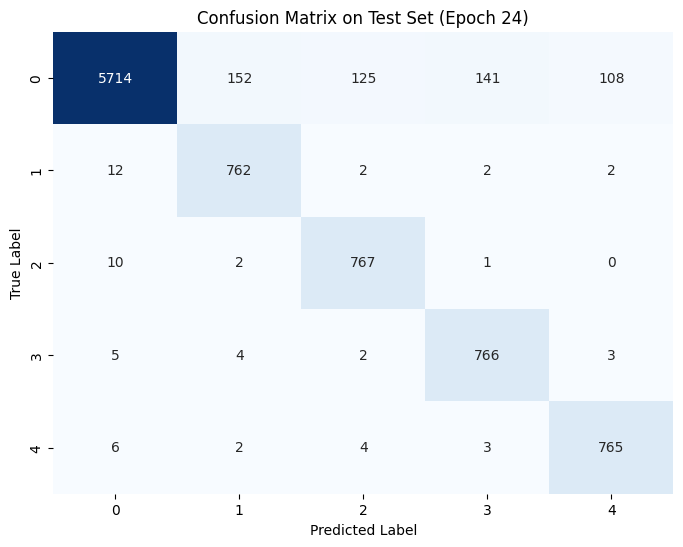


--- Confusion Matrix Explanation ---
Rows represent the TRUE LABELS (ground truth).
Columns represent the PREDICTED LABELS by the model.
Diagonal elements show correct classifications.
Off-diagonal elements show misclassifications (e.g., row 0, col 1 means samples of true class 0 were predicted as class 1).

--- Classification Report on Test Set ---
              precision    recall  f1-score   support

     Class 0     0.9943    0.9157    0.9534      6240
     Class 1     0.8265    0.9769    0.8954       780
     Class 2     0.8522    0.9833    0.9131       780
     Class 3     0.8390    0.9821    0.9049       780
     Class 4     0.8713    0.9808    0.9228       780

    accuracy                         0.9374      9360
   macro avg     0.8766    0.9678    0.9179      9360
weighted avg     0.9453    0.9374    0.9386      9360



In [ ]:
# Get the path to the latest checkpoint
latest_checkpoint_path = get_latest_checkpoint(checkpoint_dir)

if latest_checkpoint_path is None:
    print("No checkpoint found in the directory. Please ensure checkpoints are saved.")
else:
    print(f"Loading model from: {latest_checkpoint_path}")

    # Load the checkpoint
    model_test = JigNet(num_classes=5).to(device)

    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    model_test.load_state_dict(checkpoint["model_state_dict"])
    loaded_epoch = checkpoint["epoch"]

    model_test.eval()  # Set the model to evaluation mode

    all_predictions_test = []
    all_targets_test = []

    with torch.no_grad():
        for tile_a, tile_b, target in test_loader:
            tile_a = tile_a.to(device)
            tile_b = tile_b.to(device)
            target = target.to(device)

            logits = model_test(tile_a, tile_b)
            predictions = torch.argmax(logits, dim=1)

            all_predictions_test.extend(predictions.cpu().numpy())
            all_targets_test.extend(target.cpu().numpy())

    # Compute the confusion matrix
    cm_test = confusion_matrix(all_targets_test, all_predictions_test)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=range(5),
        yticklabels=range(5)
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix on Test Set (Epoch {loaded_epoch})')
    plt.show()

    print("\n--- Confusion Matrix Explanation ---")
    print("Rows represent the TRUE LABELS (ground truth).")
    print("Columns represent the PREDICTED LABELS by the model.")
    print("Diagonal elements show correct classifications.")
    print("Off-diagonal elements show misclassifications (e.g., row 0, col 1 means samples of true class 0 were predicted as class 1).")

    # Generate and print the classification report
    print("\n--- Classification Report on Test Set ---")
    target_names = [f'Class {i}' for i in range(5)]
    report = classification_report(
        all_targets_test,
        all_predictions_test,
        target_names=target_names,
        digits=4
    )
    print(report)

### Model Export
Save our best model's full architecture and state dict to a final file representation ready for runtime deployment and inference.

In [ ]:
"""
model_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model"

# Get the path to the latest checkpoint
latest_checkpoint_path = get_latest_checkpoint(checkpoint_dir)

if latest_checkpoint_path is None:
    print("No checkpoint found in the directory. Cannot save the model.")
else:
    print(f"Loading model from: {latest_checkpoint_path} to save.")

    final_model = JigNet(num_classes=5).to(device)

    # Load the state dictionary from the checkpoint
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    final_model.load_state_dict(checkpoint["model_state_dict"])

    # Set the model to evaluation mode
    final_model.eval()

    # Define the path to save the final model
    final_model_save_path = os.path.join(model_dir, "final_jignet_model.pth")

    # Save the entire model (including architecture and state_dict)
    torch.save(final_model, final_model_save_path)

    print(f"Model successfully saved to: {final_model_save_path}")
    print("You can load this model later using: `loaded_model = torch.load(final_model_save_path)`")
    print("Remember to set it to eval mode: `loaded_model.eval()` before inference.")
"""

Loading model from: /content/drive/MyDrive/Jigsaw_Puzzle_Project/JigNet_exp2_checkpoints/checkpoint_epoch_024.pth to save.
Model successfully saved to: /content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model/final_jignet_model.pth
You can load this model later using: `loaded_model = torch.load(final_model_save_path)`
Remember to set it to eval mode: `loaded_model.eval()` before inference.


**Save only the JigNet weights**

In [ ]:
# Define the directory and filename to save only the model weights (state dictionary)
weights_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model"
os.makedirs(weights_dir, exist_ok=True)
weights_save_path = os.path.join(weights_dir, "jignet_weights.pth")

# Save only the state dict
torch.save(model.state_dict(), weights_save_path)
print(f"Model weights successfully saved to: {weights_save_path}")
print("\nTo load this in another notebook:")
print("1. Copy/paste or import JigEncoder and JigNet classes.")
print("2. Run:")
print("   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')")
print("   loaded_model = JigNet(num_classes=5).to(device)")
print("   loaded_model.load_state_dict(torch.load('jignet_weights.pth', map_location=device))")
print("   loaded_model.eval()")

Model weights successfully saved to: /content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model/jignet_weights.pth

To load this in another notebook:
1. Copy/paste or import JigEncoder and JigNet classes.
2. Run:
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   loaded_model = JigNet(num_classes=5).to(device)
   loaded_model.load_state_dict(torch.load('jignet_weights.pth', map_location=device))
   loaded_model.eval()


**Finally let's export JigEncoder and JigNet classes into a .py file and upload it to drive so whenever we want to use the model we just import the file**

In [ ]:
import os

# Define the code content for the model classes
models_code = """import torch
import torch.nn as nn

class JigEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d(output_size=(2, 2)),
            nn.Flatten()
        )

    def forward(self, x):
        return self.encoder(x)

class JigNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.encoder = JigEncoder()
        feature_dim = 512
        combined_dim = feature_dim * 4

        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, tile_a, tile_b):
        feature_a = self.encoder(tile_a)
        feature_b = self.encoder(tile_b)
        diff = torch.abs(feature_a - feature_b)
        prod = feature_a * feature_b
        combined = torch.cat([feature_a, feature_b, diff, prod], dim=1)
        return self.mlp(combined)
"""

# Save the file to your Google Drive project folder
export_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model"
os.makedirs(export_dir, exist_ok=True)
export_path = os.path.join(export_dir, "jignet_models.py")

with open(export_path, "w") as f:
    f.write(models_code)

print(f"Created standalone library at: {export_path}")
print("\n--- HOW TO IMPORT IN ANOTHER NOTEBOOK ---")
print("Run the following snippet in your other notebook after mounting Google Drive:")
print("""\nimport sys\nsys.path.append('/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model')\n\nfrom jignet_models import JigNet, JigEncoder\nprint('Successfully imported classes!')""")

Created standalone library at: /content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model/jignet_models.py

--- HOW TO IMPORT IN ANOTHER NOTEBOOK ---
Run the following snippet in your other notebook after mounting Google Drive:

import sys
sys.path.append('/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model')

from jignet_models import JigNet, JigEncoder
print('Successfully imported classes!')
